In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet


In [11]:
# --------------------------------------------------
# KONFIG
# --------------------------------------------------

DATA_FILE = "bysykkel_prophet_features_3h_weather.csv"

TRAIN_START_DATE = "2020-01-01"

# Definer sesong (kan justeres)
FORECAST_START = "2026-03-01"
FORECAST_END   = "2026-10-31"


In [12]:
print("Leser og aggregerer data …")

df = pd.read_csv(DATA_FILE, parse_dates=["ds"])

df_daily = (
    df
    .set_index("ds")
    .resample("D")["y"]
    .sum()
    .reset_index()
)

df_daily = df_daily.rename(columns={"ds": "ds", "y": "y"})


Leser og aggregerer data …


In [13]:
df_daily = df_daily[df_daily["ds"] >= TRAIN_START_DATE].copy()

In [14]:
print("Trener Prophet-modell …")

m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,   # daglig data
    seasonality_mode="multiplicative"
)

m.fit(df_daily)

Trener Prophet-modell …


10:27:58 - cmdstanpy - INFO - Chain [1] start processing
10:27:59 - cmdstanpy - INFO - Chain [1] done processing


In [15]:
future = pd.DataFrame({
    "ds": pd.date_range(
        start=FORECAST_START,
        end=FORECAST_END,
        freq="D"
    )
})

forecast = m.predict(future)

In [16]:
forecast["yhat"] = forecast["yhat"].clip(lower=0)
forecast["yhat_lower"] = forecast["yhat_lower"].clip(lower=0)
forecast["yhat_upper"] = forecast["yhat_upper"].clip(lower=0)

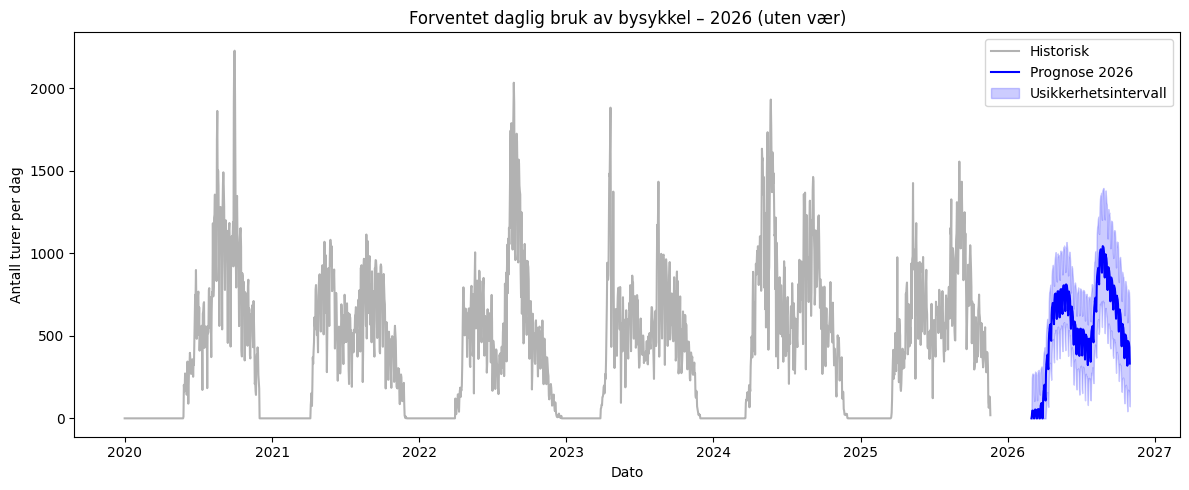

In [17]:
plt.figure(figsize=(12, 5))

# Historisk
plt.plot(
    df_daily["ds"],
    df_daily["y"],
    color="black",
    alpha=0.3,
    label="Historisk"
)

# Prognose
plt.plot(
    forecast["ds"],
    forecast["yhat"],
    color="blue",
    label="Prognose 2026"
)

# Konfidensintervall
plt.fill_between(
    forecast["ds"],
    forecast["yhat_lower"],
    forecast["yhat_upper"],
    color="blue",
    alpha=0.2,
    label="Usikkerhetsintervall"
)

plt.title("Forventet daglig bruk av bysykkel – 2026 (uten vær)")
plt.xlabel("Dato")
plt.ylabel("Antall turer per dag")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
SEASON_START = "03-01"
SEASON_END   = "10-31"


In [20]:
df_2025 = df_daily[
    (df_daily["ds"].dt.year == 2025)
].copy()

# Avgrens til sesong
df_2025 = df_2025[
    (df_2025["ds"].dt.strftime("%m-%d") >= SEASON_START) &
    (df_2025["ds"].dt.strftime("%m-%d") <= SEASON_END)
]

df_2025["day_of_season"] = (
    df_2025["ds"] - pd.to_datetime("2025-" + SEASON_START)
).dt.days


In [21]:
df_2026 = forecast[
    (forecast["ds"].dt.strftime("%m-%d") >= SEASON_START) &
    (forecast["ds"].dt.strftime("%m-%d") <= SEASON_END)
].copy()

df_2026["day_of_season"] = (
    df_2026["ds"] - pd.to_datetime("2026-" + SEASON_START)
).dt.days

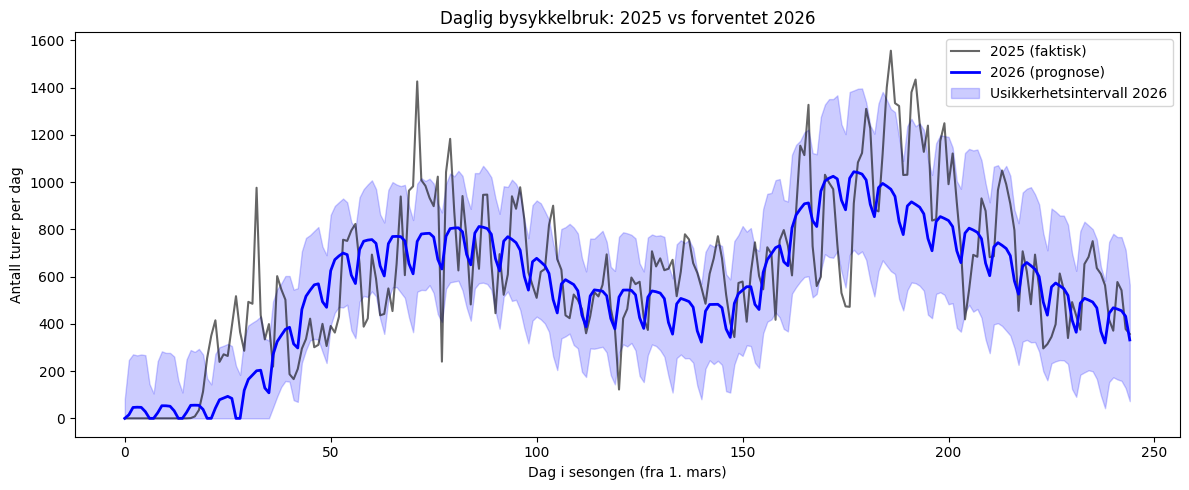

✅ Ferdig


In [22]:
plt.figure(figsize=(12, 5))

# 2025 faktisk
plt.plot(
    df_2025["day_of_season"],
    df_2025["y"],
    color="black",
    alpha=0.6,
    label="2025 (faktisk)"
)

# 2026 prognose
plt.plot(
    df_2026["day_of_season"],
    df_2026["yhat"],
    color="blue",
    linewidth=2,
    label="2026 (prognose)"
)

# Usikkerhetsintervall
plt.fill_between(
    df_2026["day_of_season"],
    df_2026["yhat_lower"],
    df_2026["yhat_upper"],
    color="blue",
    alpha=0.2,
    label="Usikkerhetsintervall 2026"
)

plt.title("Daglig bysykkelbruk: 2025 vs forventet 2026")
plt.xlabel("Dag i sesongen (fra 1. mars)")
plt.ylabel("Antall turer per dag")
plt.legend()
plt.tight_layout()
plt.show()

print("✅ Ferdig")